<a href="https://colab.research.google.com/github/asegura4488/MecanicaClasica/blob/main/Cinematica/Lenmiscatte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

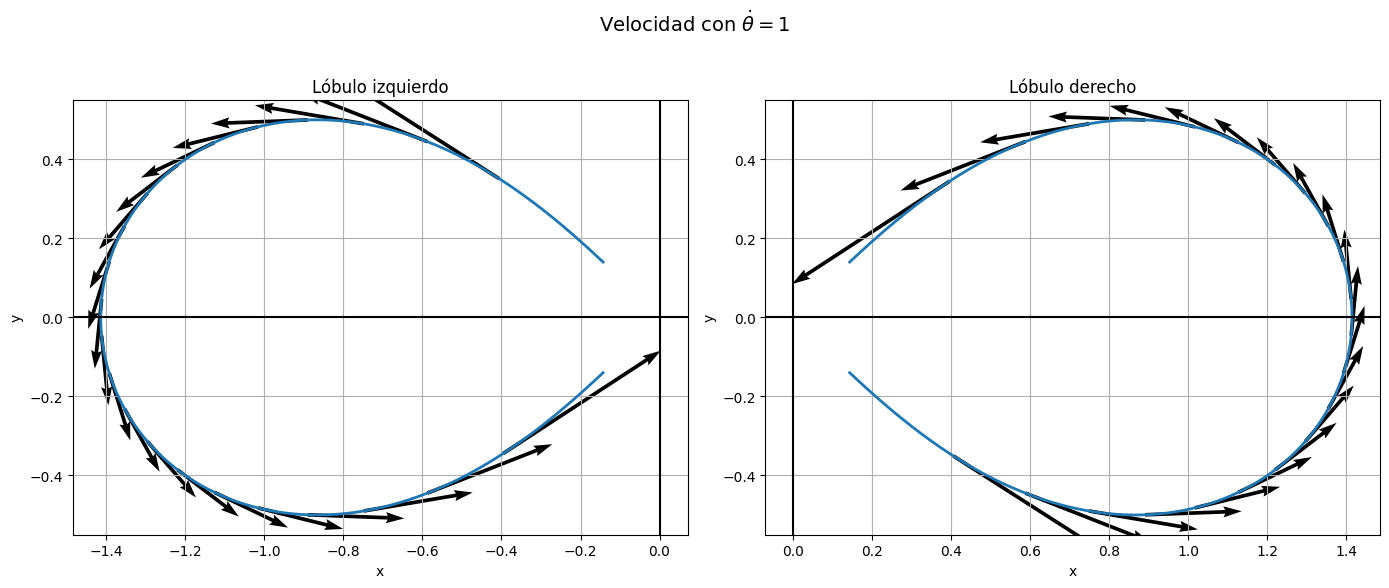

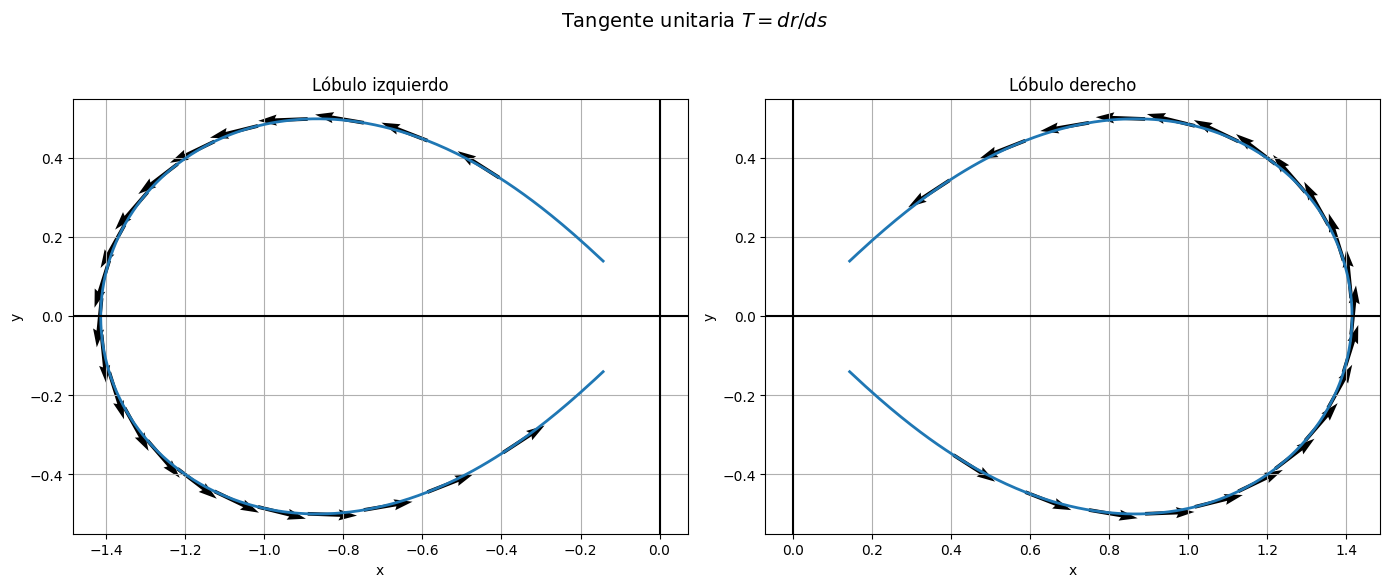

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parámetros
# =====================================================
a = 1.0
theta_dot = 1.0
eps = 0.01


# =====================================================
# Geometría común
# =====================================================
def curva(theta):

    r = np.sqrt(2*a**2*np.cos(2*theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)

    dr_dtheta = -2*a**2*np.sin(2*theta)/r

    return r,x,y,dr_dtheta


# =====================================================
# Velocidad con theta_dot constante
# =====================================================
def velocidad(theta):

    r,x,y,dr_dtheta = curva(theta)

    r_dot = dr_dtheta*theta_dot

    vx = r_dot*np.cos(theta)-r*theta_dot*np.sin(theta)
    vy = r_dot*np.sin(theta)+r*theta_dot*np.cos(theta)

    return x,y,vx,vy


# =====================================================
# Tangente unitaria (longitud de arco)
# =====================================================
def tangente(theta):

    r,x,y,dr_dtheta = curva(theta)

    dx_dtheta = dr_dtheta*np.cos(theta)-r*np.sin(theta)
    dy_dtheta = dr_dtheta*np.sin(theta)+r*np.cos(theta)

    ds_dtheta=np.sqrt(dx_dtheta**2+dy_dtheta**2)

    Tx=dx_dtheta/ds_dtheta
    Ty=dy_dtheta/ds_dtheta

    return x,y,Tx,Ty


# =====================================================
# Función general de dibujo
# =====================================================
def dibujar_dos_lobulos(func,titulo_general):

    theta_i=np.linspace(
        3*np.pi/4+eps,
        5*np.pi/4-eps,
        500
    )

    theta_d=np.linspace(
        -np.pi/4+eps,
         np.pi/4-eps,
         500
    )

    xi,yi,ui,vi=func(theta_i)
    xd,yd,ud,vd=func(theta_d)

    idx_i=np.linspace(20,len(theta_i)-20,22,dtype=int)
    idx_d=np.linspace(20,len(theta_d)-20,22,dtype=int)

    fig,axs=plt.subplots(1,2,figsize=(14,6))


    # -------------------------
    # Izquierdo
    # -------------------------
    axs[0].plot(xi,yi,lw=2)

    axs[0].quiver(
        xi[idx_i],yi[idx_i],
        ui[idx_i],vi[idx_i],
        angles='xy',
        scale_units='xy',
        scale=8,
        width=0.006
    )

    axs[0].axhline(0,color='k')
    axs[0].axvline(0,color='k')
    axs[0].set_aspect('equal')
    axs[0].grid(True)
    axs[0].set_title("Lóbulo izquierdo")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")


    # -------------------------
    # Derecho
    # -------------------------
    axs[1].plot(xd,yd,lw=2)

    axs[1].quiver(
        xd[idx_d],yd[idx_d],
        ud[idx_d],vd[idx_d],
        angles='xy',
        scale_units='xy',
        scale=8,
        width=0.006
    )

    axs[1].axhline(0,color='k')
    axs[1].axvline(0,color='k')
    axs[1].set_aspect('equal')
    axs[1].grid(True)
    axs[1].set_title("Lóbulo derecho")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")

    plt.suptitle(titulo_general,fontsize=14)
    plt.tight_layout()
    plt.show()


# =====================================================
# Figura 1: velocidad "naive"
# =====================================================

dibujar_dos_lobulos(
    velocidad,
    r'Velocidad con $\dot{\theta}=1$'
)


# =====================================================
# Figura 2: tangente unitaria
# =====================================================

dibujar_dos_lobulos(
    tangente,
    r'Tangente unitaria $T = dr/ds$'
)

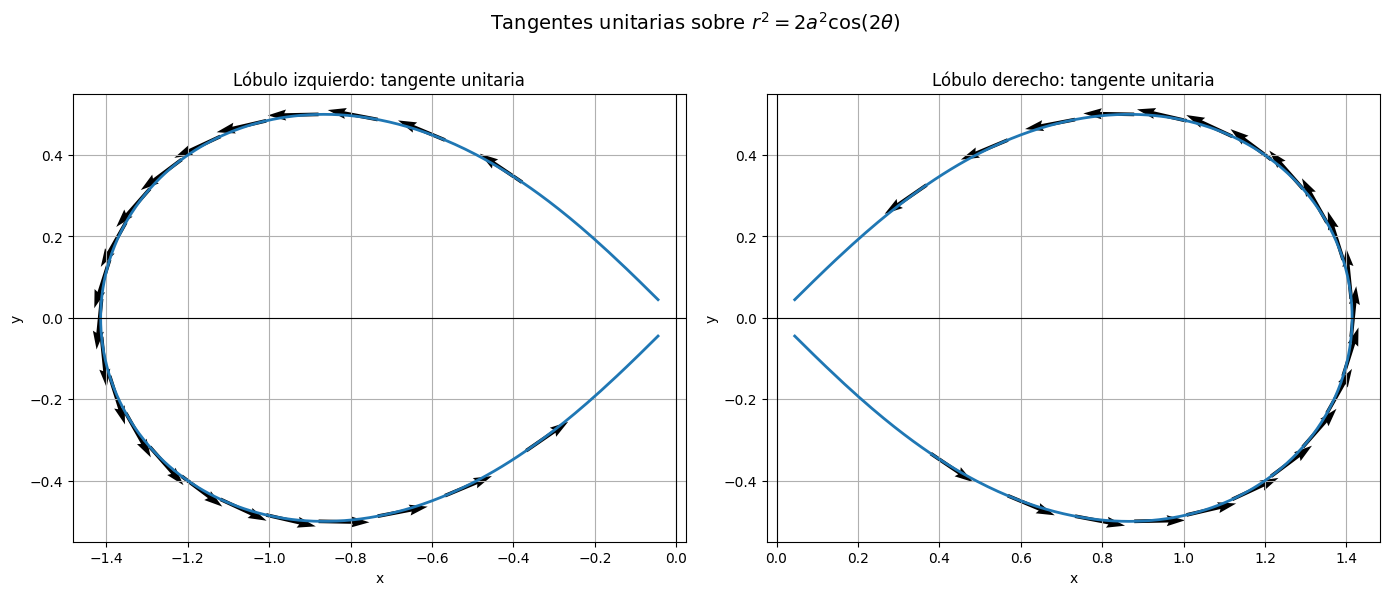

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros
# ============================================================
a = 1.0

# Evitamos exactamente el origen para no dividir entre r = 0
eps = 0.001

# ============================================================
# Función para calcular curva y tangente unitaria
# ============================================================
def calcular_lobulo(theta, a=1.0):
    r = np.sqrt(2*a**2*np.cos(2*theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)

    dr_dtheta = -2*a**2*np.sin(2*theta)/r

    dx_dtheta = dr_dtheta*np.cos(theta) - r*np.sin(theta)
    dy_dtheta = dr_dtheta*np.sin(theta) + r*np.cos(theta)

    ds_dtheta = np.sqrt(dx_dtheta**2 + dy_dtheta**2)

    # Tangente unitaria
    Tx = dx_dtheta / ds_dtheta
    Ty = dy_dtheta / ds_dtheta

    return x, y, Tx, Ty


# ============================================================
# Rangos de theta
# ============================================================
theta_izq = np.linspace(3*np.pi/4 + eps, 5*np.pi/4 - eps, 500)
theta_der = np.linspace(-np.pi/4 + eps, np.pi/4 - eps, 500)

# Calculamos
x_i, y_i, Tx_i, Ty_i = calcular_lobulo(theta_izq, a)
x_d, y_d, Tx_d, Ty_d = calcular_lobulo(theta_der, a)

# Índices para no dibujar demasiadas flechas
idx_i = np.linspace(20, len(theta_izq)-20, 22, dtype=int)
idx_d = np.linspace(20, len(theta_der)-20, 22, dtype=int)

# ============================================================
# Figura con dos subplots
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ----------------------------
# Lóbulo izquierdo
# ----------------------------
axs[0].plot(x_i, y_i, lw=2)
axs[0].quiver(
    x_i[idx_i], y_i[idx_i],
    Tx_i[idx_i], Ty_i[idx_i],
    angles="xy",
    scale_units="xy",
    scale=8,
    width=0.006
)

axs[0].axhline(0, color="k", linewidth=0.8)
axs[0].axvline(0, color="k", linewidth=0.8)
axs[0].set_aspect("equal")
axs[0].grid(True)
axs[0].set_title("Lóbulo izquierdo: tangente unitaria")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

# ----------------------------
# Lóbulo derecho
# ----------------------------
axs[1].plot(x_d, y_d, lw=2)
axs[1].quiver(
    x_d[idx_d], y_d[idx_d],
    Tx_d[idx_d], Ty_d[idx_d],
    angles="xy",
    scale_units="xy",
    scale=8,
    width=0.006
)

axs[1].axhline(0, color="k", linewidth=0.8)
axs[1].axvline(0, color="k", linewidth=0.8)
axs[1].set_aspect("equal")
axs[1].grid(True)
axs[1].set_title("Lóbulo derecho: tangente unitaria")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

plt.suptitle(r"Tangentes unitarias sobre $r^2 = 2a^2\cos(2\theta)$", fontsize=14)
plt.tight_layout()
plt.show()